In [177]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### 1. Environment Setup & Data Loading

In [178]:
df = pd.read_csv(filepath_or_buffer="All_State_NCRB_Crime_Data_2014.csv")
df.head()

,States/UTs,District,Year,Murder,Attempt to commit Murder,Culpable Homicide not amounting to Murder,Attempt to commit Culpable Homicide,Rape,Custodial Rape,Custodial_Gang Rape,...,Offences promoting enmity between different groups,Promoting enmity between different groups,"Imputation, assertions prejudicial to national integration",Extortion,Disclosure of Identity of Victims,Incidence of Rash Driving,HumanTrafficking,Unnatural Offence,Other IPC crimes,Total Cognizable IPC crimes
0,Andhra Pradesh,Anantapur,2014,134,171,8,0,35,0,0,...,0,0,0,0,0,1038,0,0,3800,8376
1,Andhra Pradesh,Chittoor,2014,84,170,2,0,32,0,0,...,0,0,0,19,0,249,0,0,2567,5374
2,Andhra Pradesh,Cuddapah,2014,80,162,1,0,28,0,0,...,0,0,0,0,0,948,0,0,2604,5803
3,Andhra Pradesh,East Godavari,2014,64,84,2,0,85,0,0,...,0,0,0,32,0,39,0,0,3791,7630
4,Andhra Pradesh,Guntakal Railway,2014,14,4,0,0,0,0,0,...,0,0,0,0,0,1,0,0,37,490


In [179]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 838 entries, 0 to 837
Data columns (total 91 columns):
 #   Column                                                            Non-Null Count  Dtype
---  ------                                                            --------------  -----
 0   States/UTs                                                        838 non-null    str  
 1   District                                                          838 non-null    str  
 2   Year                                                              838 non-null    int64
 3   Murder                                                            838 non-null    int64
 4   Attempt to commit Murder                                          838 non-null    int64
 5   Culpable Homicide not amounting to Murder                         838 non-null    int64
 6   Attempt to commit Culpable Homicide                               838 non-null    int64
 7   Rape                                                            

In [180]:
NUMERICAL_COLS = df.select_dtypes(include=np.number).columns
CATEGORICAL_COLS = df.select_dtypes(include="str").columns

In [181]:
len((df["States/UTs"]).value_counts())

36

### 2. Separation of Aggregates vs. District Granularity

In [182]:
df.head()

,States/UTs,District,Year,Murder,Attempt to commit Murder,Culpable Homicide not amounting to Murder,Attempt to commit Culpable Homicide,Rape,Custodial Rape,Custodial_Gang Rape,...,Offences promoting enmity between different groups,Promoting enmity between different groups,"Imputation, assertions prejudicial to national integration",Extortion,Disclosure of Identity of Victims,Incidence of Rash Driving,HumanTrafficking,Unnatural Offence,Other IPC crimes,Total Cognizable IPC crimes
0,Andhra Pradesh,Anantapur,2014,134,171,8,0,35,0,0,...,0,0,0,0,0,1038,0,0,3800,8376
1,Andhra Pradesh,Chittoor,2014,84,170,2,0,32,0,0,...,0,0,0,19,0,249,0,0,2567,5374
2,Andhra Pradesh,Cuddapah,2014,80,162,1,0,28,0,0,...,0,0,0,0,0,948,0,0,2604,5803
3,Andhra Pradesh,East Godavari,2014,64,84,2,0,85,0,0,...,0,0,0,32,0,39,0,0,3791,7630
4,Andhra Pradesh,Guntakal Railway,2014,14,4,0,0,0,0,0,...,0,0,0,0,0,1,0,0,37,490


In [183]:
df_district = df[df["District"] != "Total"]
df_state_totals = df[df["District"] == "Total"]

if (
    df_district["Total Cognizable IPC crimes"].sum()
    == df_state_totals["Total Cognizable IPC crimes"].sum()
):
    print("No double-counting included")
else:
    print("There is some double-counting")


No double-counting included


### 3. Identifying Special Administrative Units (Railway & Crime Branch Districts)

In [184]:
non_standard_places = ["Railway", "Crime Branch", "CID"]

pattern = "|".join(non_standard_places)

non_standard_districts = df[
    df["District"].str.contains(
        pattern,
        case=False,
        na=False,
        regex=True,
    )
]

non_standard_districts.head()

,States/UTs,District,Year,Murder,Attempt to commit Murder,Culpable Homicide not amounting to Murder,Attempt to commit Culpable Homicide,Rape,Custodial Rape,Custodial_Gang Rape,...,Offences promoting enmity between different groups,Promoting enmity between different groups,"Imputation, assertions prejudicial to national integration",Extortion,Disclosure of Identity of Victims,Incidence of Rash Driving,HumanTrafficking,Unnatural Offence,Other IPC crimes,Total Cognizable IPC crimes
4,Andhra Pradesh,Guntakal Railway,2014,14,4,0,0,0,0,0,...,0,0,0,0,0,1,0,0,37,490
15,Andhra Pradesh,Vijayawada Railway,2014,1,1,1,0,0,0,0,...,0,0,0,1,0,0,0,0,59,1223
23,Arunachal Pradesh,Crime Branch,2014,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
84,Bihar,Jamalpur Railway,2014,9,1,0,0,0,0,0,...,0,0,0,2,0,0,0,0,72,298
88,Bihar,Katihar Railway,2014,10,9,0,0,0,0,0,...,0,0,0,0,0,0,3,0,61,313


In [185]:
avg_murder_df = non_standard_districts.groupby(["States/UTs", "District"]).agg(
    avg_murder=("Murder", "mean"),
)

avg_murder_df.head()

avg_murder
States/UTs        District                      
Andhra Pradesh    Guntakal Railway          14.0
                  Vijayawada Railway         1.0
Arunachal Pradesh Crime Branch               0.0
Bihar             Jamalpur Railway           9.0
                  Katihar Railway           10.0

### 4. State-Wise Ranking of Cognizable Crimes

In [186]:
state_wise_crimes = (
    df_state_totals.groupby("States/UTs")
    .agg(
        total_crime=("Total Cognizable IPC crimes", "sum"),
    )
    .reset_index()
)

TOTAL_CRIME_ACROSS_STATES = state_wise_crimes["total_crime"].sum()

state_wise_crimes["distribution_perc"] = np.round(
    (state_wise_crimes["total_crime"] / TOTAL_CRIME_ACROSS_STATES) * 100, 2
)

state_wise_crimes = state_wise_crimes.sort_values(
    by="distribution_perc", ascending=False
).reset_index()

top5 = state_wise_crimes.head(5)
bottom5 = state_wise_crimes.tail(5)

In [187]:
top5

,index,States/UTs,total_crime,distribution_perc
0,19,Madhya Pradesh,272423,9.53
1,20,Maharashtra,249834,8.74
2,33,Uttar Pradesh,240475,8.41
3,28,Rajasthan,210418,7.36
4,17,Kerala,206789,7.23


In [188]:
bottom5

,index,States/UTs,total_crime,distribution_perc
31,29,Sikkim,1065,0.04
32,0,A&N Islands,746,0.03
33,8,Daman & Diu,233,0.01
34,7,D&N Haveli,277,0.01
35,18,Lakshadweep,81,0.00


### 5. Analysis of Violent Crimes Against Person

In [189]:
df_state_totals.head()

,States/UTs,District,Year,Murder,Attempt to commit Murder,Culpable Homicide not amounting to Murder,Attempt to commit Culpable Homicide,Rape,Custodial Rape,Custodial_Gang Rape,...,Offences promoting enmity between different groups,Promoting enmity between different groups,"Imputation, assertions prejudicial to national integration",Extortion,Disclosure of Identity of Victims,Incidence of Rash Driving,HumanTrafficking,Unnatural Offence,Other IPC crimes,Total Cognizable IPC crimes
20,Andhra Pradesh,Total,2014,1175,1540,52,1,961,0,0,...,21,21,0,276,0,14653,2,1,44187,114604
40,Arunachal Pradesh,Total,2014,86,48,4,0,83,4,0,...,0,0,0,121,0,102,0,0,720,2843
69,Assam,Total,2014,1451,1142,57,14,1980,0,0,...,0,0,0,1226,0,3202,68,0,29212,94337
116,Bihar,Total,2014,3403,4379,201,463,1127,0,0,...,0,0,0,972,0,3485,44,5,75799,177595
145,Chhattisgarh,Total,2014,998,716,29,0,1436,0,0,...,3,3,0,74,0,7759,43,22,21897,58200


In [190]:
violent_crimes = df_state_totals.copy(deep=True)

target_cols = [
    "Murder",
    "Attempt to commit Murder",
    "Culpable Homicide not amounting to Murder",
    "Attempt to commit Culpable Homicide",
]

violent_crimes["Violent_Crimes_Person"] = df[target_cols].sum(axis=1)

violent_crimes = violent_crimes[["States/UTs", "Violent_Crimes_Person"]].reset_index()
violent_crimes.head(10)

,index,States/UTs,Violent_Crimes_Person
0,20,Andhra Pradesh,2768
1,40,Arunachal Pradesh,138
2,69,Assam,2664
3,116,Bihar,8446
4,145,Chhattisgarh,1743
5,149,Goa,82
6,191,Gujarat,1940
7,216,Haryana,1963
8,232,Himachal Pradesh,202
9,263,Jammu & Kashmir,660


### 6. Property Crime Analysis (Theft & Burglary)

In [191]:
target_cols = [
    "Auto Theft",
    "Robbery",
    "Dacoity",
    "Criminal Trespass/Burglary",
]

property_crime = df_state_totals[["States/UTs"] + target_cols]
property_crime["Total Theft"] = df_state_totals[target_cols].sum(axis=1)
TOTAL_THEFT = property_crime["Total Theft"].sum()
property_crime = property_crime.sort_values(
    by="Total Theft",
    ascending=False,
).reset_index()

In [192]:
# Percentage of national total theft contributed by this state/UT
property_crime["pct_of_national_theft"] = np.round(
    property_crime["Total Theft"] * 100 / TOTAL_THEFT, 2
)

# Percentage of a state's total theft that consists of auto theft
property_crime["pct_auto_in_state_theft"] = np.round(
    property_crime["Auto Theft"] * 100 / property_crime["Total Theft"], 2
)

In [193]:
property_crime.head()

,index,States/UTs,Auto Theft,Robbery,Dacoity,Criminal Trespass/Burglary,Total Theft,pct_of_national_theft,pct_auto_in_state_theft
0,452,Maharashtra,20433,9466,885,17171,47955,13.97,42.61
1,756,Uttar Pradesh,29561,3920,294,6921,40696,11.86,72.64
2,832,Delhi UT,23384,6464,82,10309,40239,11.72,58.11
3,405,Madhya Pradesh,15323,1969,105,12110,29507,8.60,51.93
4,606,Rajasthan,17015,1301,64,6379,24759,7.21,68.72


### 7. Public Order & Riot Breakdown

In [194]:
riots_related_cols = []
riots_df = pd.DataFrame()
riots_df["states/UTs"] = df_state_totals["States/UTs"]
for col in df_state_totals.columns:
    if "Riots_" in col:
        riots_related_cols.append(col.lower())
        riots_df[col.lower()] = df_state_totals[col]

riots_df["total_riots"] = riots_df[riots_related_cols].sum(axis=1)

In [195]:
riots_df = riots_df.sort_values(by="total_riots", ascending=False).reset_index()

TOTAL_RIOTS = riots_df["total_riots"].sum()

# Percentage of national total riots contributed by this state/UT
riots_df["pct_of_national_riots"] = np.round(
    riots_df["total_riots"] * 100 / TOTAL_RIOTS, 2
)

In [196]:
riots_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   index                        36 non-null     int64  
 1   states/UTs                   36 non-null     str    
 2   riots_communal               36 non-null     int64  
 3   riots_industrial             36 non-null     int64  
 4   riots_political              36 non-null     int64  
 5   riots_caste conflict         36 non-null     int64  
 6   riots_sc/sts vs non-scs/sts  36 non-null     int64  
 7   riots_other caste conflict   36 non-null     int64  
 8   riots_agrarian               36 non-null     int64  
 9   riots_students               36 non-null     int64  
 10  riots_sectarian              36 non-null     int64  
 11  riots_others                 36 non-null     int64  
 12  total_riots                  36 non-null     int64  
 13  pct_of_national_riots        36 n

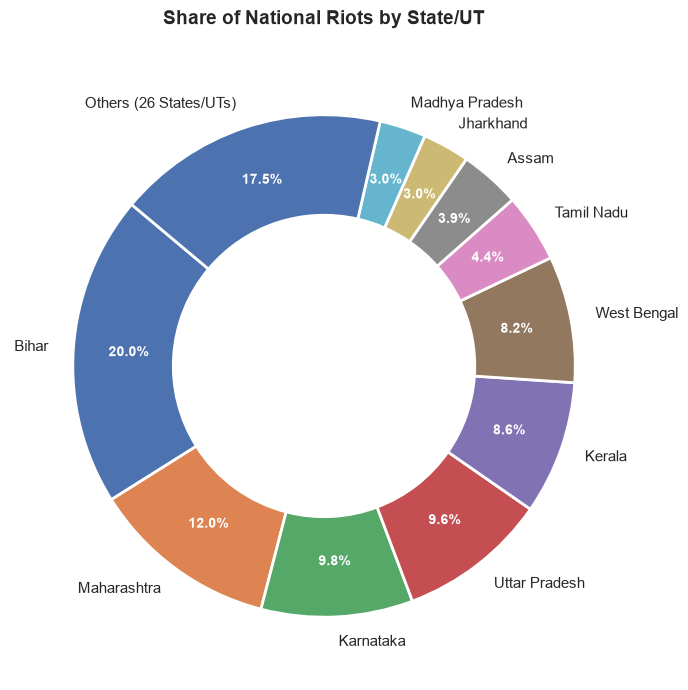

In [197]:
df_sorted = riots_df.sort_values(by="pct_of_national_riots", ascending=False)

# Extract Top N states and aggregate the rest as "Others".
# There are too many states and plotting them inside of one pie chart will make it unreadable.
top_n = 10
df_top = df_sorted.iloc[:top_n].copy()
others_pct = df_sorted.iloc[top_n:]["pct_of_national_riots"].sum()

plot_df = pd.concat(
    [
        df_top[["states/UTs", "pct_of_national_riots"]],
        pd.DataFrame(
            [
                {
                    "states/UTs": f"Others ({len(riots_df) - top_n} States/UTs)",
                    "pct_of_national_riots": round(others_pct, 2),
                }
            ]
        ),
    ],
    ignore_index=True,
)

plt.figure(figsize=(9, 7), dpi=100)

wedges, texts, autotexts = plt.pie(
    plot_df["pct_of_national_riots"],
    labels=plot_df["states/UTs"],
    autopct="%1.1f%%",
    pctdistance=0.78,
    startangle=140,
    wedgeprops={
        "width": 0.4,
        "edgecolor": "white",
        "linewidth": 2,
    },  # NOTE: width < 1 creates the donut hole
)

for autotext in autotexts:
    autotext.set_weight("bold")
    autotext.set_color("white")

plt.title("Share of National Riots by State/UT", fontsize=14, pad=20, fontweight="bold")
plt.tight_layout()
plt.show()


### 8. Comprehensive Analysis of Crimes Against Women

In [198]:
target_cols = [
    "Rape",
    "Attempt to commit Rape",
    "Dowry Deaths",
    "Cruelty by Husband or his Relatives",
    "Assault on Women with intent to outrage her Modesty",
    "Sexual Harassment",
    "Stalking",
    "Voyeurism",
    "Importation of Girls from Foreign Country",
]

crime_agnst_women = df_state_totals[["States/UTs"] + target_cols]
crime_agnst_women.columns = crime_agnst_women.columns.str.lower().str.replace(" ", "_")
target_cols = [col.lower().replace(" ", "_") for col in target_cols]

In [199]:
TOTAL_CRIME_AGAINST_WOMEN = crime_agnst_women[target_cols].sum()
crime_agnst_women["total_crime_against_women"] = crime_agnst_women[target_cols].sum(
    axis=1
)

crime_agnst_women = crime_agnst_women.sort_values(
    by="total_crime_against_women",
    ascending=False,
).reset_index()

In [200]:
crime_agnst_women.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 12 columns):
 #   Column                                               Non-Null Count  Dtype
---  ------                                               --------------  -----
 0   index                                                36 non-null     int64
 1   states/uts                                           36 non-null     str  
 2   rape                                                 36 non-null     int64
 3   attempt_to_commit_rape                               36 non-null     int64
 4   dowry_deaths                                         36 non-null     int64
 5   cruelty_by_husband_or_his_relatives                  36 non-null     int64
 6   assault_on_women_with_intent_to_outrage_her_modesty  36 non-null     int64
 7   sexual_harassment                                    36 non-null     int64
 8   stalking                                             36 non-null     int64
 9   voyeurism              

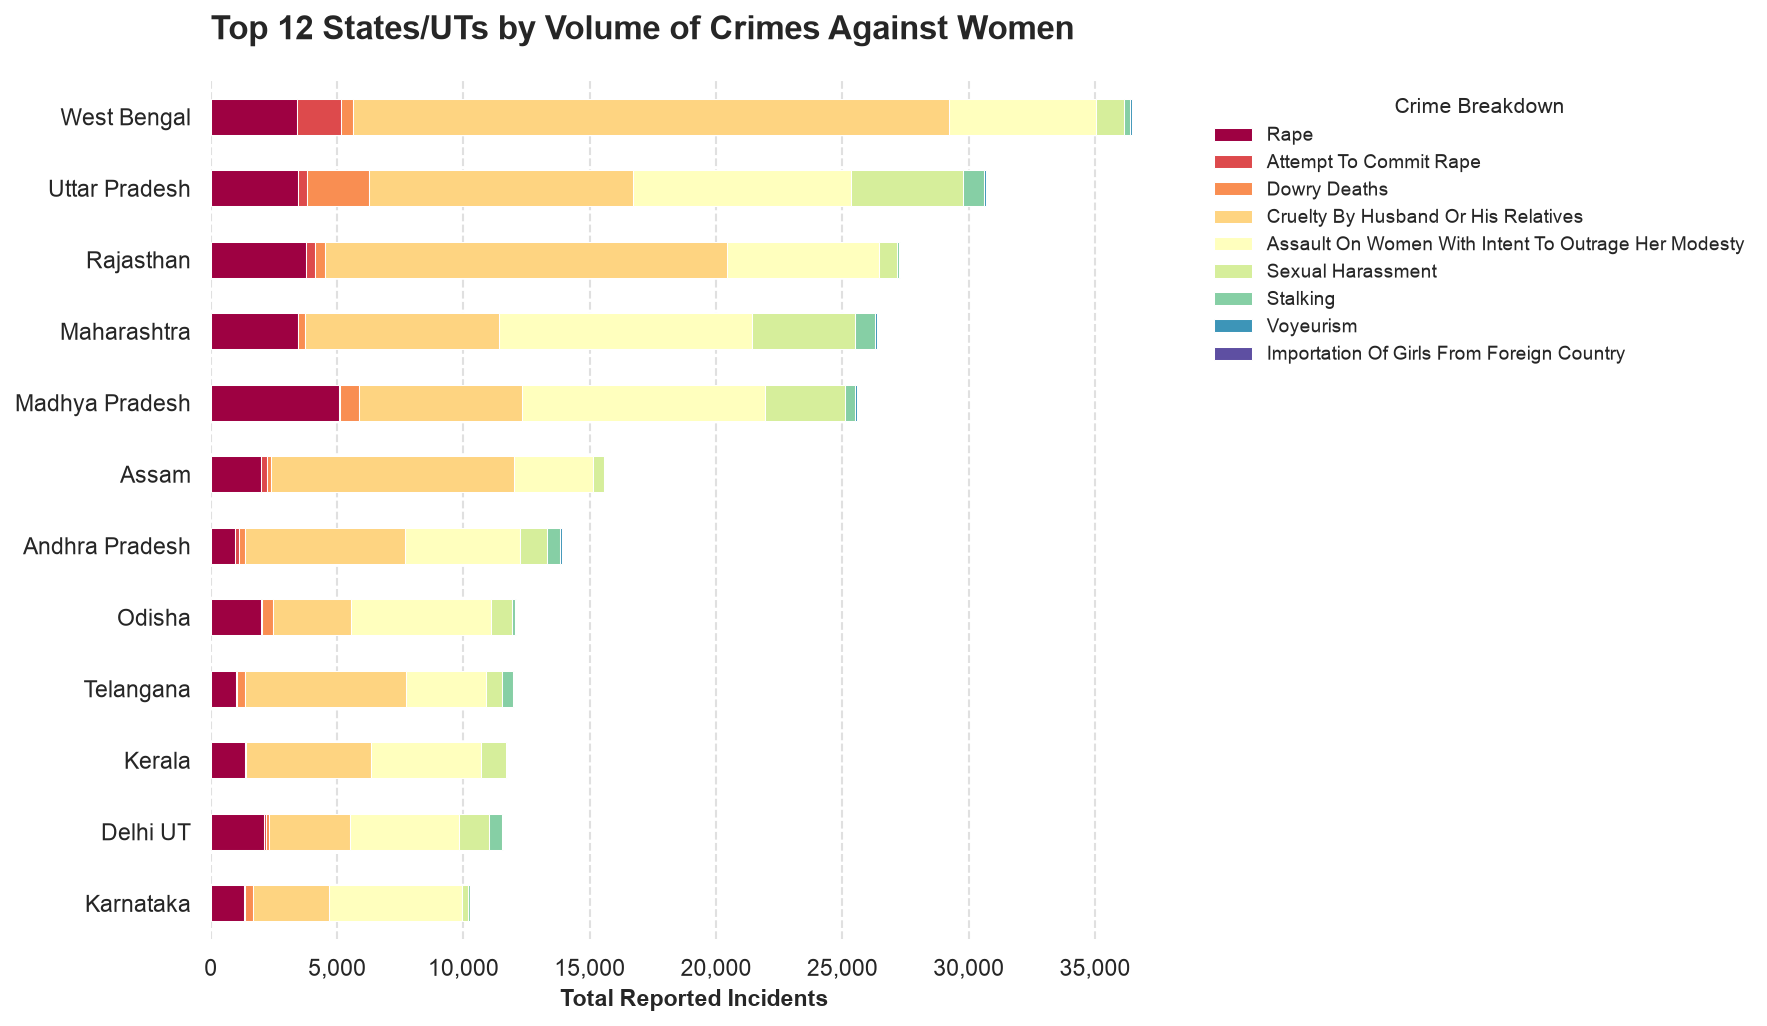

In [201]:
df = crime_agnst_women.copy(deep=True)

sns.set_theme(style="whitegrid", font="sans-serif")
plt.rcParams["font.family"] = "sans-serif"

exclude_cols = ["index", "states/uts", "total_crime_against_women"]
feature_cols = [col for col in crime_agnst_women.columns if col not in exclude_cols]

top_12 = df.sort_values(by="total_crime_against_women", ascending=False).head(12)

plot_data = top_12.set_index("states/uts")[feature_cols]

plot_data.columns = [col.replace("_", " ").title() for col in plot_data.columns]

fig, ax = plt.subplots(figsize=(12, 7), dpi=150)

plot_data.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    colormap="Spectral",
    edgecolor="white",
    linewidth=0.5,
)

ax.invert_yaxis()  # NOTE: Highest total at top
ax.set_title(
    "Top 12 States/UTs by Volume of Crimes Against Women",
    fontsize=16,
    fontweight="bold",
    pad=20,
    loc="left",
)
ax.set_xlabel("Total Reported Incidents", fontsize=11, fontweight="bold")
ax.set_ylabel("", fontsize=11)

ax.xaxis.set_major_formatter("{x:,.0f}")

sns.despine(left=True, bottom=True)
ax.xaxis.grid(True, linestyle="--", alpha=0.6)
ax.yaxis.grid(False)

ax.legend(
    title="Crime Breakdown",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=9,
    title_fontsize=10,
)

plt.tight_layout()
plt.show()


### 9. Micro-Analysis of Rape Sub-Categories

In [202]:
rape_cols = [col for col in df_state_totals.columns if "Rape" in col]
rape_df = df_state_totals[["States/UTs"] + rape_cols].drop(
    columns=["Rape", "Rape other than Custodial"]
)

In [203]:
rape_cols.remove("Rape")
rape_cols.remove("Rape other than Custodial")

TOTAL_RAPE_INCIDENTS = rape_df[rape_cols].sum()
rape_df["rape_incidents"] = rape_df[rape_cols].sum(axis=1)

In [204]:
rape_df = (
    rape_df.sort_values(
        by="rape_incidents",
        ascending=False,
    )
    .reset_index()
    .drop(columns="index")
)

In [205]:
rape_df.head()

,States/UTs,Custodial Rape,Custodial_Gang Rape,Custodial_Other Rape,Rape_Gang Rape,Rape_Others,Attempt to commit Rape,rape_incidents
0,West Bengal,1,0,1,184,3224,1732,5142
1,Madhya Pradesh,0,0,0,284,4792,56,5132
2,Rajasthan,3,2,1,414,3342,373,4135
3,Uttar Pradesh,189,5,184,573,2705,324,3980
4,Maharashtra,0,0,0,126,3312,15,3453


In [206]:
# NOTE: "Rape_Others" column will be dropped
# because it provides no value while distorting analysis/graphs.

rape_df = rape_df.drop(columns="Rape_Others")

In [207]:
rape_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   States/UTs              36 non-null     str  
 1   Custodial Rape          36 non-null     int64
 2   Custodial_Gang Rape     36 non-null     int64
 3   Custodial_Other Rape    36 non-null     int64
 4   Rape_Gang Rape          36 non-null     int64
 5   Attempt to commit Rape  36 non-null     int64
 6   rape_incidents          36 non-null     int64
dtypes: int64(6), str(1)
memory usage: 2.1 KB


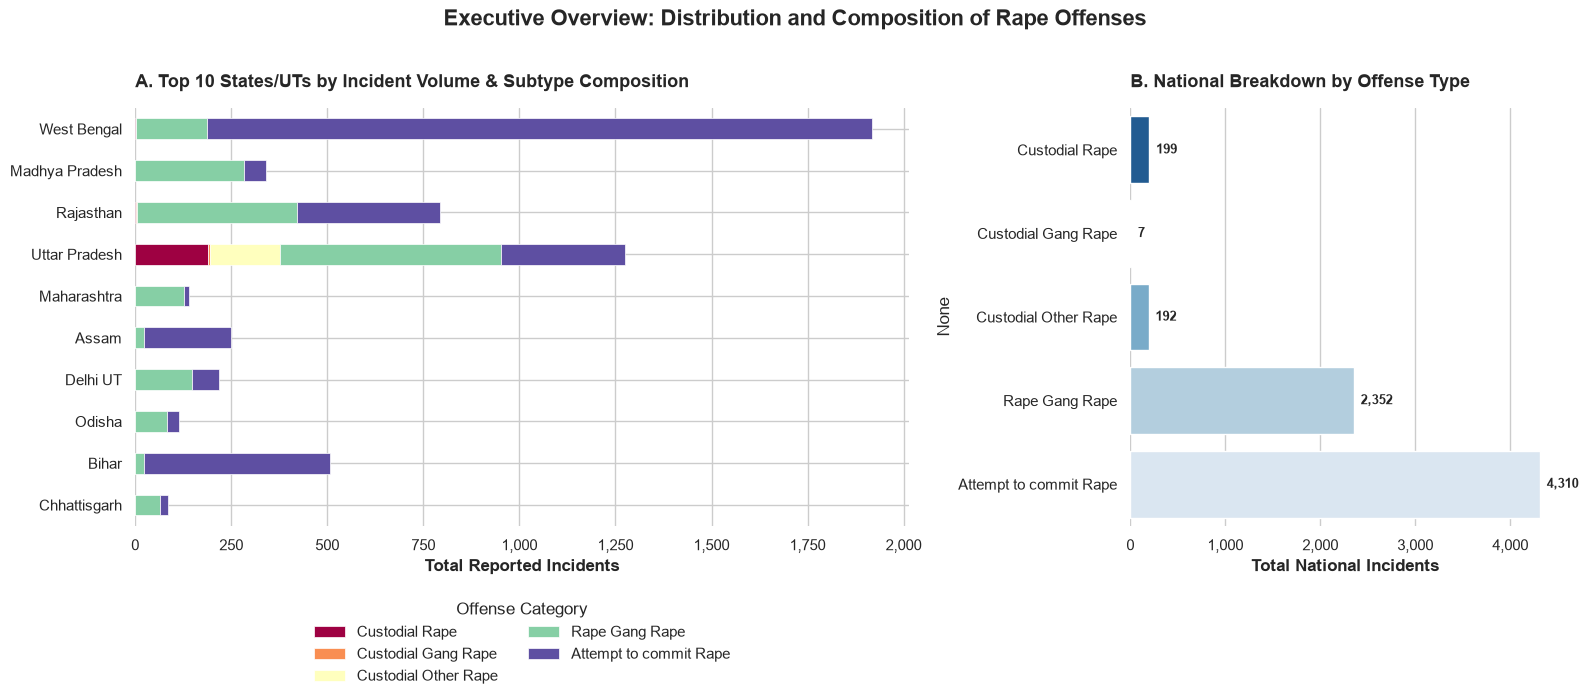

In [208]:
sns.set_theme(style="whitegrid", font="sans-serif")
plt.rcParams["font.size"] = 10

sub_categories = [
    "Custodial Rape",
    "Custodial_Gang Rape",
    "Custodial_Other Rape",
    "Rape_Gang Rape",
    "Attempt to commit Rape",
]

clean_labels = [c.replace("_", " ") for c in sub_categories]

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [1.8, 1]}
)

top_10 = rape_df.sort_values(by="rape_incidents", ascending=False).head(10)
plot_data = top_10.set_index("States/UTs")[sub_categories]
plot_data.columns = clean_labels

plot_data.plot(
    kind="barh",
    stacked=True,
    ax=ax1,
    colormap="Spectral",
    edgecolor="white",
    linewidth=0.5,
)

ax1.invert_yaxis()
ax1.set_title(
    "A. Top 10 States/UTs by Incident Volume & Subtype Composition",
    fontsize=13,
    fontweight="bold",
    pad=15,
    loc="left",
)
ax1.set_xlabel("Total Reported Incidents", fontweight="bold")
ax1.set_ylabel("")
ax1.xaxis.set_major_formatter("{x:,.0f}")
ax1.legend(
    title="Offense Category",
    bbox_to_anchor=(0.5, -0.15),
    loc="upper center",
    ncol=2,
    frameon=False,
)
sns.despine(ax=ax1, left=True, bottom=True)

national_totals = rape_df[sub_categories].sum()
national_totals.index = clean_labels

sns.barplot(
    x=national_totals.values,
    y=national_totals.index,
    hue=national_totals.index,
    legend=False,
    ax=ax2,
    palette="Blues_r",
    orient="h",
)

ax2.set_title(
    "B. National Breakdown by Offense Type",
    fontsize=13,
    fontweight="bold",
    pad=15,
    loc="left",
)
ax2.set_xlabel("Total National Incidents", fontweight="bold")
ax2.xaxis.set_major_formatter("{x:,.0f}")

for p in ax2.patches:
    width = p.get_width()
    ax2.annotate(
        f"{int(width):,}",
        (width, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
    )

sns.despine(ax=ax2, left=True, bottom=True)

plt.suptitle(
    "Executive Overview: Distribution and Composition of Rape Offenses",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()
